# Amazon Fine Food Reviews — Week 1  
## _Data Understanding & Exploratory Data Analysis_

---

## Project Overview

**Project Type:** Sentiment Classification (NLP)  
**Dataset Source:** Kaggle — Amazon Fine Food Reviews (~500,000 reviews)  
**Working Dataset:** _Balanced subset of 30,000 reviews_  
**Stage:** *Week 1 of 4-week NLP pipeline*  
**Last Updated:** _May 2026_

---

## 1. Motivation & Problem Definition

### _Why this problem matters?_

Online reviews are one of the most important sources of understanding customer experience. However, manual analysis is not practical because:

- Large-scale data is generated continuously  
- Manual labeling is slow and not scalable  
- Human interpretation introduces bias  
- Businesses lose valuable insights due to delays  

---

### Objective

The goal of this project is to build an NLP system capable of automatically classifying sentiment in food reviews:

- **Positive**
- **Negative**

This system can be used for:

- customer feedback monitoring  
- product quality analysis  
- decision-making support in business  

---

## 2. Model Approach

We experiment with multiple NLP models to compare performance:

- **TF-IDF + Logistic Regression** → baseline model (fast & interpretable)  
- **LSTM / BiLSTM** → captures sequential dependencies in text  
- **BERT** → contextual deep language representation model  

This allows us to evaluate how model complexity affects accuracy.

---

## 3. Dataset Description

- ~500,000 Amazon food reviews  
- Ratings converted into sentiment labels  
- Two classes:
  - **Positive** (Score > 3)  
  - **Negative** (Score ≤ 3)  

### Working Dataset Strategy

To ensure efficiency and stability:

- A **balanced subset of 30,000 samples** is used  
- Helps reduce training time  
- Ensures stable model learning
- Reduces computational cost  

---

## 4. Data Preprocessing Pipeline

Before training models, the text undergoes preprocessing:

- removal of noise (HTML, punctuation, symbols)  
- conversion to lowercase  
- tokenization of text  
- optional stopword removal  
- transformation into model-ready format (TF-IDF / embeddings)  

---

## Notes

This stage focuses on:
- understanding dataset structure  
- preparing clean and balanced data  
- setting baseline assumptions for model training  



## Setup

In [22]:
import pandas as pd

df = pd.read_csv('Reviews.csv', engine='python', on_bad_lines='warn')

# балансируем по Score
df_pos = df[df['Score'] > 3].sample(15000, random_state=42)
df_neg = df[df['Score'] <= 3].sample(15000, random_state=42)

df_30k = pd.concat([df_pos, df_neg]).sample(frac=1, random_state=42)

print(df_30k['Score'].value_counts())

Score
5    12282
1     6354
3     5105
2     3541
4     2718
Name: count, dtype: int64


In [23]:
import sys
sys.path.insert(0, 'src')

## 1. Load Raw Dataset

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

RAW_PATH = 'Reviews.csv'
df_raw = pd.read_csv(RAW_PATH, engine='python', on_bad_lines='warn')
print(f'Shape: {df_raw.shape}')
df_raw.head(3)

Shape: (568454, 10)


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...


In [25]:
# Basic information
print('Columns:', df_raw.columns.tolist())
print('\nDtype summary:')
print(df_raw.dtypes)
print('\nMissing values:')
print(df_raw.isnull().sum())

Columns: ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']

Dtype summary:
Id                         int64
ProductId                 object
UserId                    object
ProfileName               object
HelpfulnessNumerator       int64
HelpfulnessDenominator     int64
Score                      int64
Time                       int64
Summary                   object
Text                      object
dtype: object

Missing values:
Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64


## 2. Score Distribution

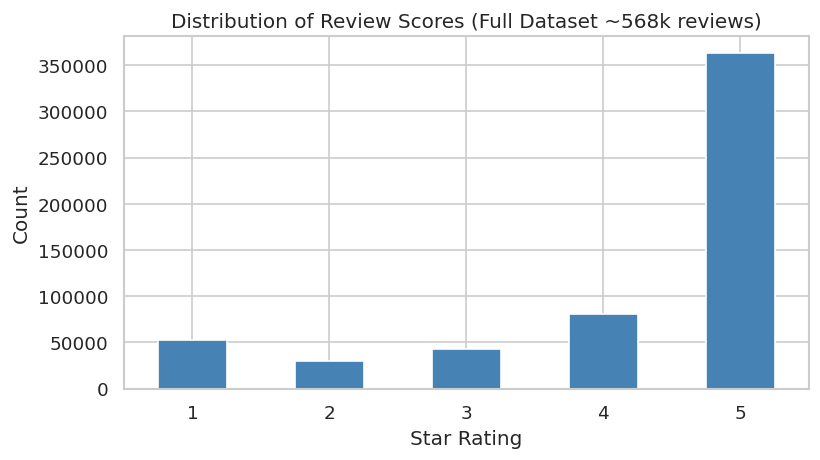

Score
5    363122
4     80655
1     52268
3     42640
2     29769
Name: count, dtype: int64


In [26]:
fig, ax = plt.subplots(figsize=(7, 4))
df_raw['Score'].value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Star Rating')
ax.set_ylabel('Count')
ax.set_title('Distribution of Review Scores (Full Dataset ~568k reviews)')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
os.makedirs('results/figures', exist_ok=True)
plt.savefig('results/figures/score_distribution.png', dpi=150)
plt.show()
print(df_raw['Score'].value_counts())

## 3. Create Balanced 30k Subset

In [27]:
# Run the data_loader script to create the balanced subset
from data_loader import load_and_balance, OUT_DIR, OUT_PATH

os.makedirs(OUT_DIR, exist_ok=True)
df = load_and_balance(RAW_PATH)
df.to_csv(OUT_PATH, index=False)
print(f'Saved to {OUT_PATH}')
print(f'Shape: {df.shape}')
print(df['label'].value_counts())

[1/4] Reading Reviews.csv …
      Raw rows: 568,454
[2/4] After removing Score=3: 525,814 rows
      Label distribution:
label
1    443777
0     82037
[3/4] Sampling 15,000 per class …
Saved to data/processed/reviews_30k.csv
Shape: (30000, 5)
label
0    15000
1    15000
Name: count, dtype: int64


## 4. Review Text Length Analysis

Word count statistics:
         count  mean   std  min   25%   50%    75%     max
label                                                     
0      15000.0  89.8  91.5  7.0  38.8  65.0  109.0  2149.0
1      15000.0  76.6  74.0  7.0  32.0  54.0   92.0  1350.0


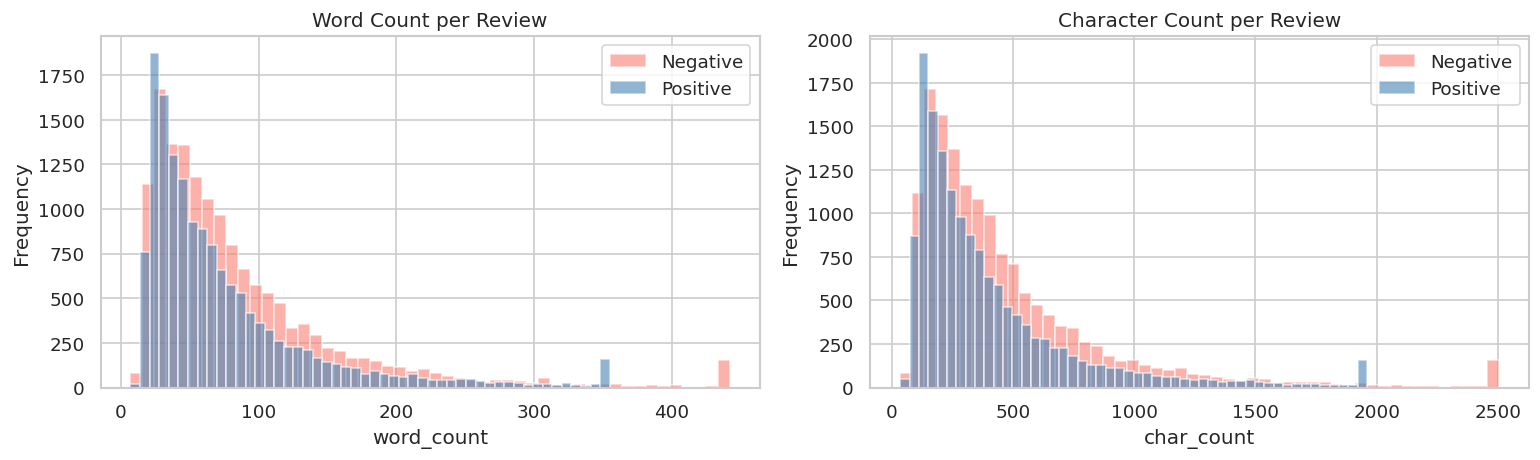

In [28]:
df['word_count'] = df['Text'].apply(lambda t: len(str(t).split()))
df['char_count'] = df['Text'].apply(lambda t: len(str(t)))

print('Word count statistics:')
print(df.groupby('label')['word_count'].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, title in zip(
    axes,
    ['word_count', 'char_count'],
    ['Word Count per Review', 'Character Count per Review']
):
    for label, color, name in [(0, 'salmon', 'Negative'), (1, 'steelblue', 'Positive')]:
        subset = df[df['label'] == label][col]
        # Cap at 99th percentile for readability
        cap = int(subset.quantile(0.99))
        ax.hist(subset.clip(upper=cap), bins=50, alpha=0.6, color=color, label=name)
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.savefig('results/figures/text_length_distribution.png', dpi=150)
plt.show()

## 5. Most Common Words

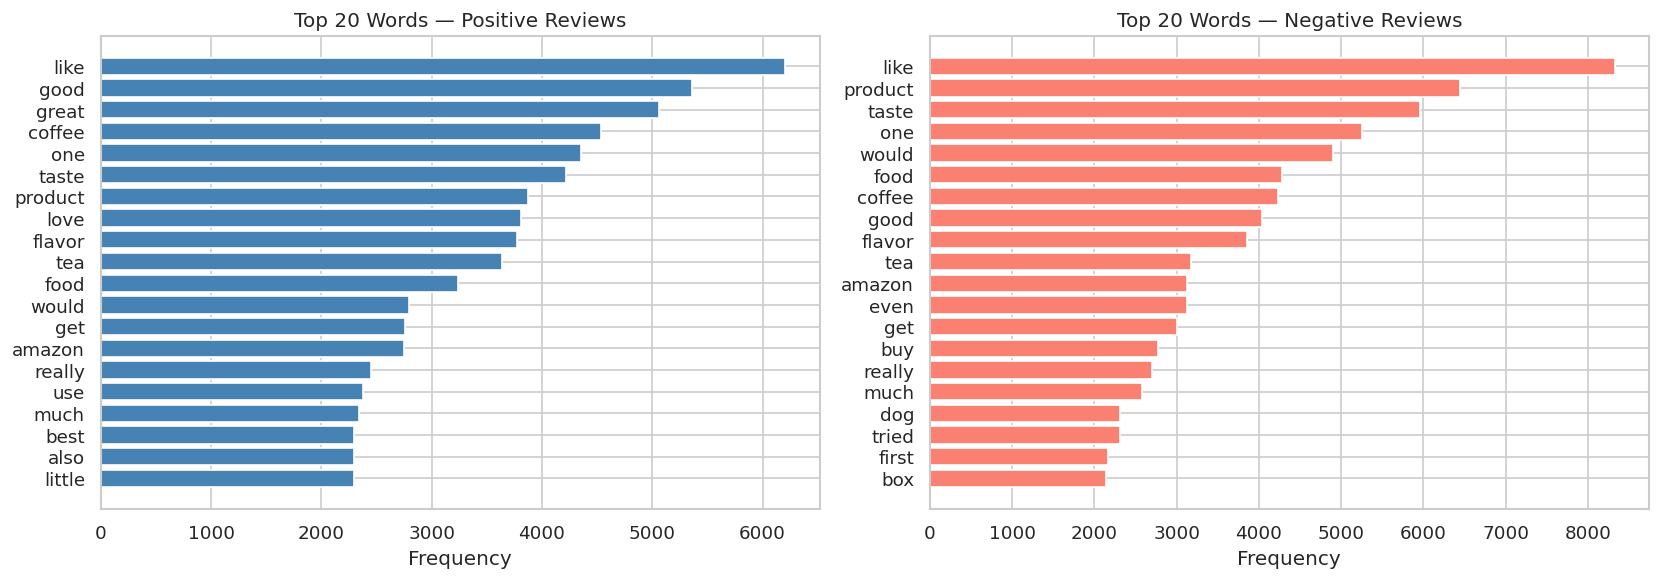

In [21]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)
STOP = set(stopwords.words('english'))

def top_words(texts, n=20):
    words = []
    for t in texts:
        clean = re.sub(r'[^a-z ]', ' ', str(t).lower())
        words.extend([w for w in clean.split() if w not in STOP and len(w) > 2])
    return Counter(words).most_common(n)

top_pos = top_words(df[df['label'] == 1]['Text'])
top_neg = top_words(df[df['label'] == 0]['Text'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, data, title, color in [
    (axes[0], top_pos, 'Top 20 Words — Positive Reviews', 'steelblue'),
    (axes[1], top_neg, 'Top 20 Words — Negative Reviews', 'salmon'),
]:
    words, counts = zip(*data)
    ax.barh(words[::-1], counts[::-1], color=color)
    ax.set_title(title)
    ax.set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('results/figures/top_words.png', dpi=150)
plt.show()

## 6. Sample Reviews

In [29]:
print('=== 3 POSITIVE REVIEWS ===')
for _, row in df[df['label'] == 1].sample(3, random_state=1).iterrows():
    print(f'[Score {row["Score"]}] {row["Text"][:200]}\n')

print('=== 3 NEGATIVE REVIEWS ===')
for _, row in df[df['label'] == 0].sample(3, random_state=1).iterrows():
    print(f'[Score {row["Score"]}] {row["Text"][:200]}\n')

=== 3 POSITIVE REVIEWS ===
[Score 4] I have tried most of the flavored K-Cups coffees.  When I saw "Island Coconut" advertised I just had to try it too!  It smells delicious just sitting on the table, but the aroma gets really yummy the 

[Score 5] Couldn't find this in the locals stores so was lucky to find it on Amazon as it is my husband's favorite breakfast food.  The cereal was a little broken up from the extra handling but that is to be ex

[Score 5] Excellent product - we use this for pizza crust and no one would be able to guess that it is gluten-free!

=== 3 NEGATIVE REVIEWS ===
[Score 1] Just opened Greenies Joint Care (individually sealed) in December 2011 and found small worm crawling all over it.  Next one looked fine, but really supposed to trust these now?

[Score 1] I ordered Rosemary Lentil Chips. THEY SENT 24 BAGS of cracked pepper. I can't have pepper! Instead of saying they are out of stock, they figured they'd send whatever and I wouldn't notice. Then they s

[Scor

## 7. Dataset Summary Table

In [30]:
summary = {
    'Total reviews (subset)': len(df),
    'Positive reviews':        int((df['label'] == 1).sum()),
    'Negative reviews':        int((df['label'] == 0).sum()),
    'Avg words per review':    round(df['word_count'].mean(), 1),
    'Median words per review': round(df['word_count'].median(), 1),
    'Max words':               int(df['word_count'].max()),
    'Missing text values':     int(df['Text'].isnull().sum()),
}
for k, v in summary.items():
    print(f'{k:<35}: {v}')

Total reviews (subset)             : 30000
Positive reviews                   : 15000
Negative reviews                   : 15000
Avg words per review               : 83.2
Median words per review            : 59.0
Max words                          : 2149
Missing text values                : 0
